In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

---
### 1. Data Loading
Let's load the artists and tracks datasets. Make sure the `artists.csv` and `tracks.csv` files are in the correct path.

In [52]:
# Make sure the file paths are correct
try:
    artists_df = pd.read_csv('../prepared_datasets/artists.csv')
    tracks_df = pd.read_csv('../prepared_datasets/tracks.csv')
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Check that the paths '../prepared_datasets/artists.csv' and '../prepared_datasets/tracks.csv' are correct.")

Data loaded successfully.


---
### 2. Feature Aggregation (Feature Engineering)
To create a unique musical profile for each artist, we aggregate the features of their songs by calculating the average.

In [53]:
# Select only the numerical columns that describe the musical style
numeric_cols = tracks_df.select_dtypes(include=[np.number]).columns
cols_to_drop = ['disc_number', 'track_number']
cols_to_agg = [c for c in numeric_cols if c not in cols_to_drop]

# Group by Artist ID and calculate the mean
tracks_agg = tracks_df.groupby('id_artist')[cols_to_agg].mean().reset_index()

print("Average musical profile calculated for each artist.")
tracks_agg.head()

Average musical profile calculated for each artist.


,id_artist,explicit,swear_IT,swear_EN,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,...,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,duration_ms,popularity,album_release_year
0,ART02449272,0.368421,0.210526,0.684211,48.315789,376.421053,7.676843,3.771378,0.416563,23.278613,...,1.153268,0.207374,0.054216,0.884142,22.309689,1872.602626,21.737868,186080.210526,16.789474,2019.578947
1,ART02666525,0.733333,3.466667,0.200000,56.966667,458.866667,8.202290,3.909500,0.513657,7.642120,...,1.262133,0.257200,0.073543,0.841987,32.964437,2144.547113,28.840727,163624.600000,23.700000,2022.900000
2,ART02733420,0.720670,2.659218,0.368715,71.530726,604.307263,8.657275,4.060222,0.514847,7.261259,...,1.257841,0.259291,0.063545,0.871535,30.397359,2290.414903,29.135935,224272.927374,44.402235,2015.770950
3,ART03111237,0.256410,0.461538,0.076923,53.410256,445.102564,8.868618,3.912917,0.508970,6.359688,...,1.321585,0.231290,0.070641,0.847264,28.808923,2083.063215,24.844197,208200.769231,19.435897,2010.717949
4,ART04141409,0.802432,2.331307,1.285714,57.401216,502.522796,8.806828,4.035050,0.518194,8.415184,...,1.284097,0.233958,0.065006,0.872816,27.610705,2347.237344,25.498205,201447.589666,41.446809,2017.370821


---
### 3. Merge Datasets
We merge the artists' geographical and biographical information with their aggregated musical profile.

In [54]:
# Merge the two DataFrames. Note: 'id_author' in artists.csv and 'id_artist' in tracks.csv
merged_df = pd.merge(artists_df, tracks_agg, left_on='id_author', right_on='id_artist', how='inner')

# Prepare the dataset for clustering by removing IDs and handling missing values
features_df = merged_df.drop(columns=['id_author', 'id_artist'])
features_df = features_df.dropna()

print(f"Dataset ready for clustering. Artists: {features_df.shape[0]}, Features: {features_df.shape[1]}")

Dataset ready for clustering. Artists: 87, Features: 25


---
### 4. Standardization (Scaling)
We scale all features to the same range (mean 0, standard deviation 1) to prevent any single feature from dominating the others.

In [55]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)
print("Features standardized.")

Features standardized.


---
### 5. Hierarchical Clustering and Dendrogram
We compute the linkage matrix using the 'ward' method and display the dendrogram to decide on the number of clusters.

Calculating models and cophenetic coefficient...


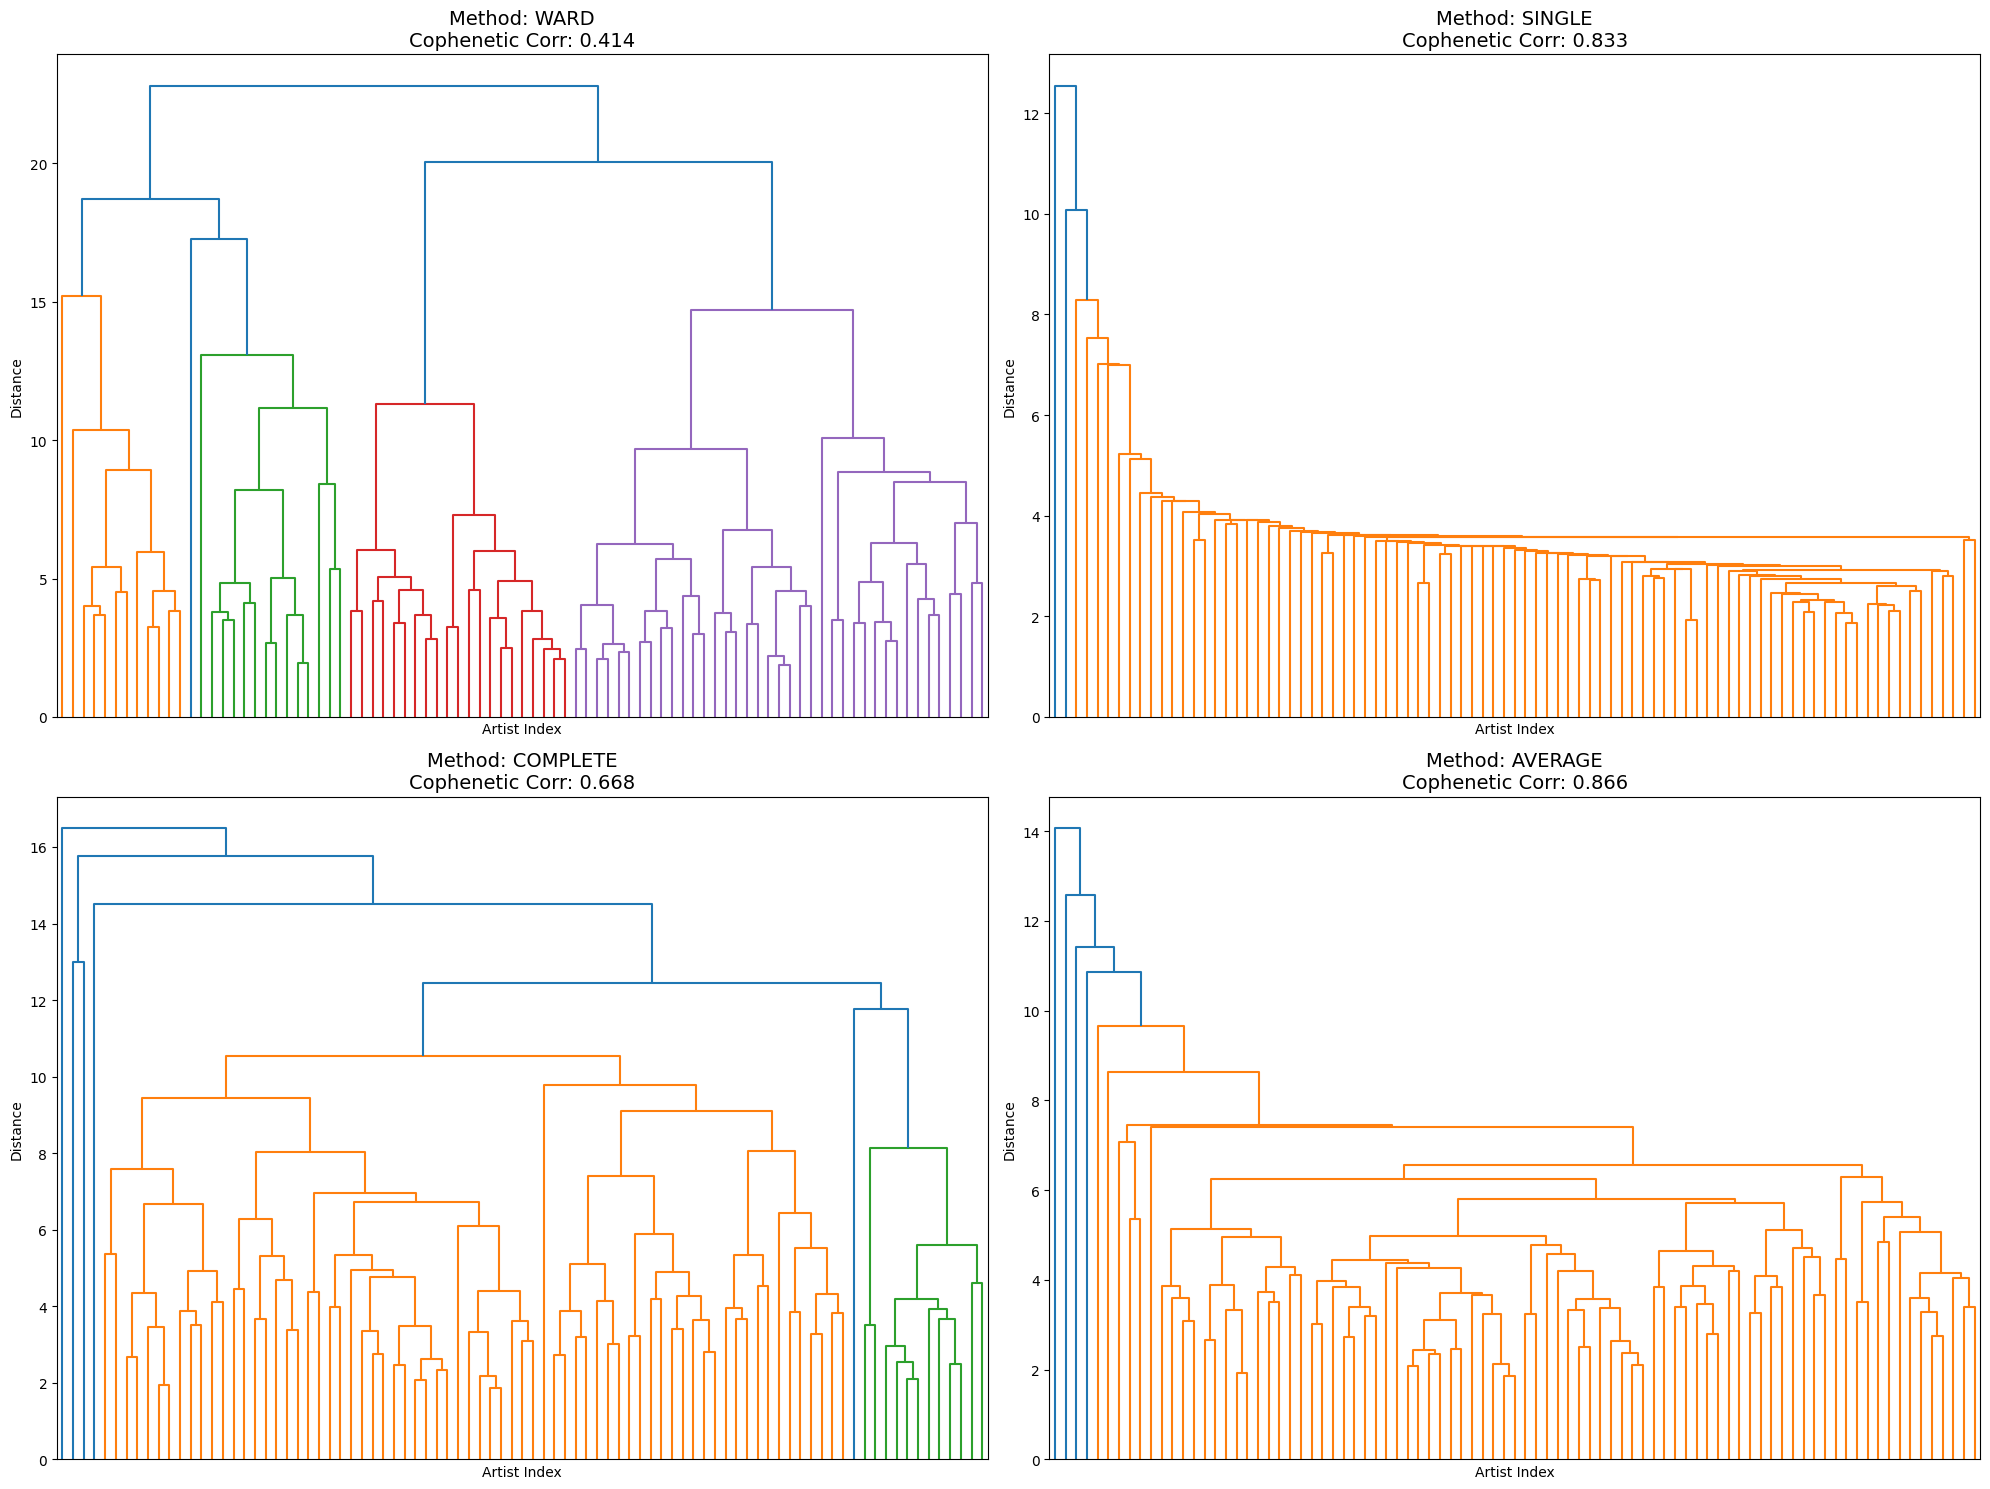


--- Methods Ranking (Cophenetic Correlation) ---
AVERAGE: 0.866
SINGLE: 0.833
COMPLETE: 0.668
WARD: 0.414

The mathematically best method is: AVERAGE


In [56]:
methods = ['ward', 'single', 'complete', 'average']
plt.figure(figsize=(20, 15))

results = {}

# Calulate the distance matrix once (Euclidean distance)
# pdist computes the pairwise distances between observations in n-dimensional space
pdist_matrix = pdist(features_scaled)

print("Calculating models and cophenetic coefficient...")

for i, method in enumerate(methods):
    # 1. Calculate the linkage matrix
    Z = linkage(features_scaled, method=method)
    
    # 2. Calculate the Cophenetic Correlation Coefficient
    # This value (c) indicates how faithfully the dendrogram preserves the original distances.
    # The closer to 1, the better the representation.
    c, coph_dists = cophenet(Z, pdist_matrix)
    results[method] = c
    
    # 3. Plot the Dendrogram
    plt.subplot(2, 2, i+1)
    plt.title(f'Method: {method.upper()}\nCophenetic Corr: {c:.3f}', fontsize=14)
    plt.xlabel('Artist Index')
    plt.ylabel('Distance')
    dendrogram(Z, no_labels=True, leaf_rotation=90., leaf_font_size=8.)

plt.tight_layout()
plt.show()

# Print the ranking of methods
print("\n--- Methods Ranking (Cophenetic Correlation) ---")
sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)
for method, score in sorted_results:
    print(f"{method.upper()}: {score:.3f}")

# Select the best method for the next steps (or the preferred one for interpretability)
best_method_math = sorted_results[0][0]
print(f"\nThe mathematically best method is: {best_method_math.upper()}")

### Results Interpretation
Although the Average and Single methods show very high cophenetic correlation coefficients (>0.8), visual analysis of the dendrograms reveals the chaining phenomenon, making them unsuitable for effective market segmentation.

The Ward method, despite a lower coefficient (0.414), produces the most balanced and interpretable tree structure, minimizing intra-cluster variance. For this reason, Ward is the definitive choice for proceeding with cutting the dendrogram and identifying the musical profiles.

---
### 6. Cluster Assignment
We choose a number of clusters (k) by observing the dendrogram and assign each artist to a cluster.

In [61]:
# We choose the number of clusters (k) by looking at the dendrogram.
# A cut at y=125 suggests about 4 clusters.
k = 4
Z = linkage(features_scaled, method="ward")
clusters = fcluster(Z, k, criterion='maxclust')

# Add the clusters to the original DataFrame for analysis
# Note: we must use the indices from the DataFrame after removing NaNs
original_indices = features_df.index
merged_df_filtered = merged_df.loc[original_indices]
merged_df_filtered['cluster'] = clusters

print(f"Assigned {len(np.unique(clusters))} clusters.")

Assigned 4 clusters.


#### B. Principal Component Analysis (PCA)
We use PCA to reduce the feature dimensionality to 2 components and visualize the cluster separation in a mathematical space.

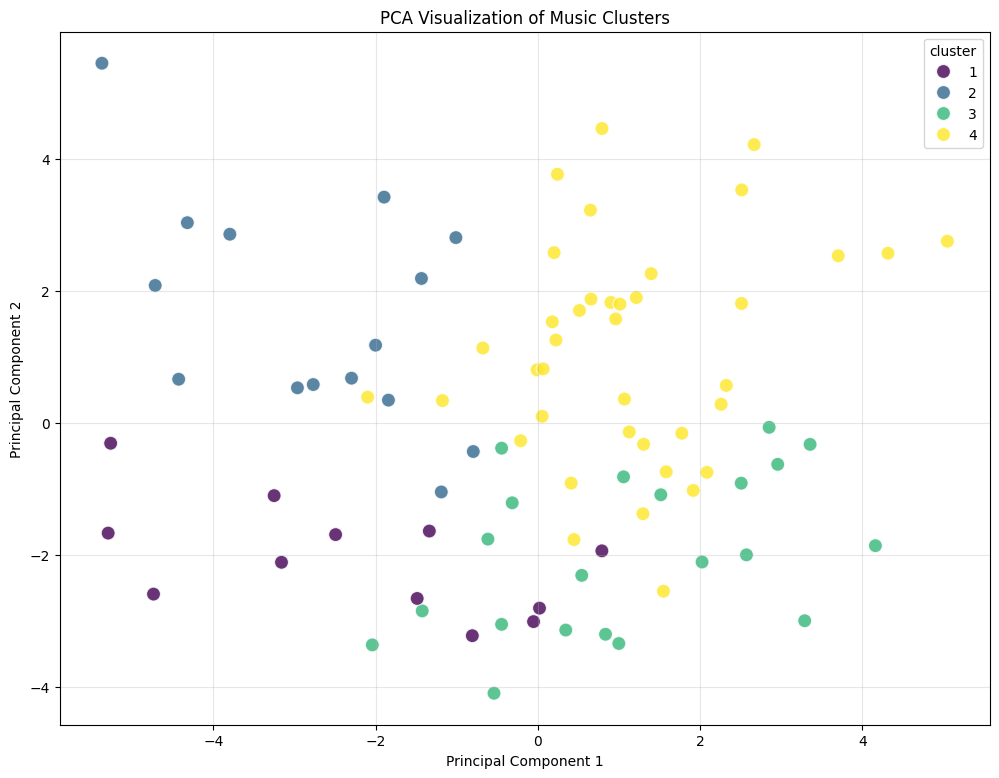

In [62]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

plt.figure(figsize=(12, 9))
sns.scatterplot(
    data=pca_df, 
    x='PC1', y='PC2', 
    hue='cluster', palette='viridis', s=100, alpha=0.8
)
plt.title('PCA Visualization of Music Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

---
### 8. Cluster Analysis
Let's count how many artists belong to each cluster.

In [63]:
print("Number of artists per cluster:")
print(merged_df_filtered['cluster'].value_counts().sort_index())

Number of artists per cluster:
cluster
1    12
2    15
3    21
4    39
Name: count, dtype: int64


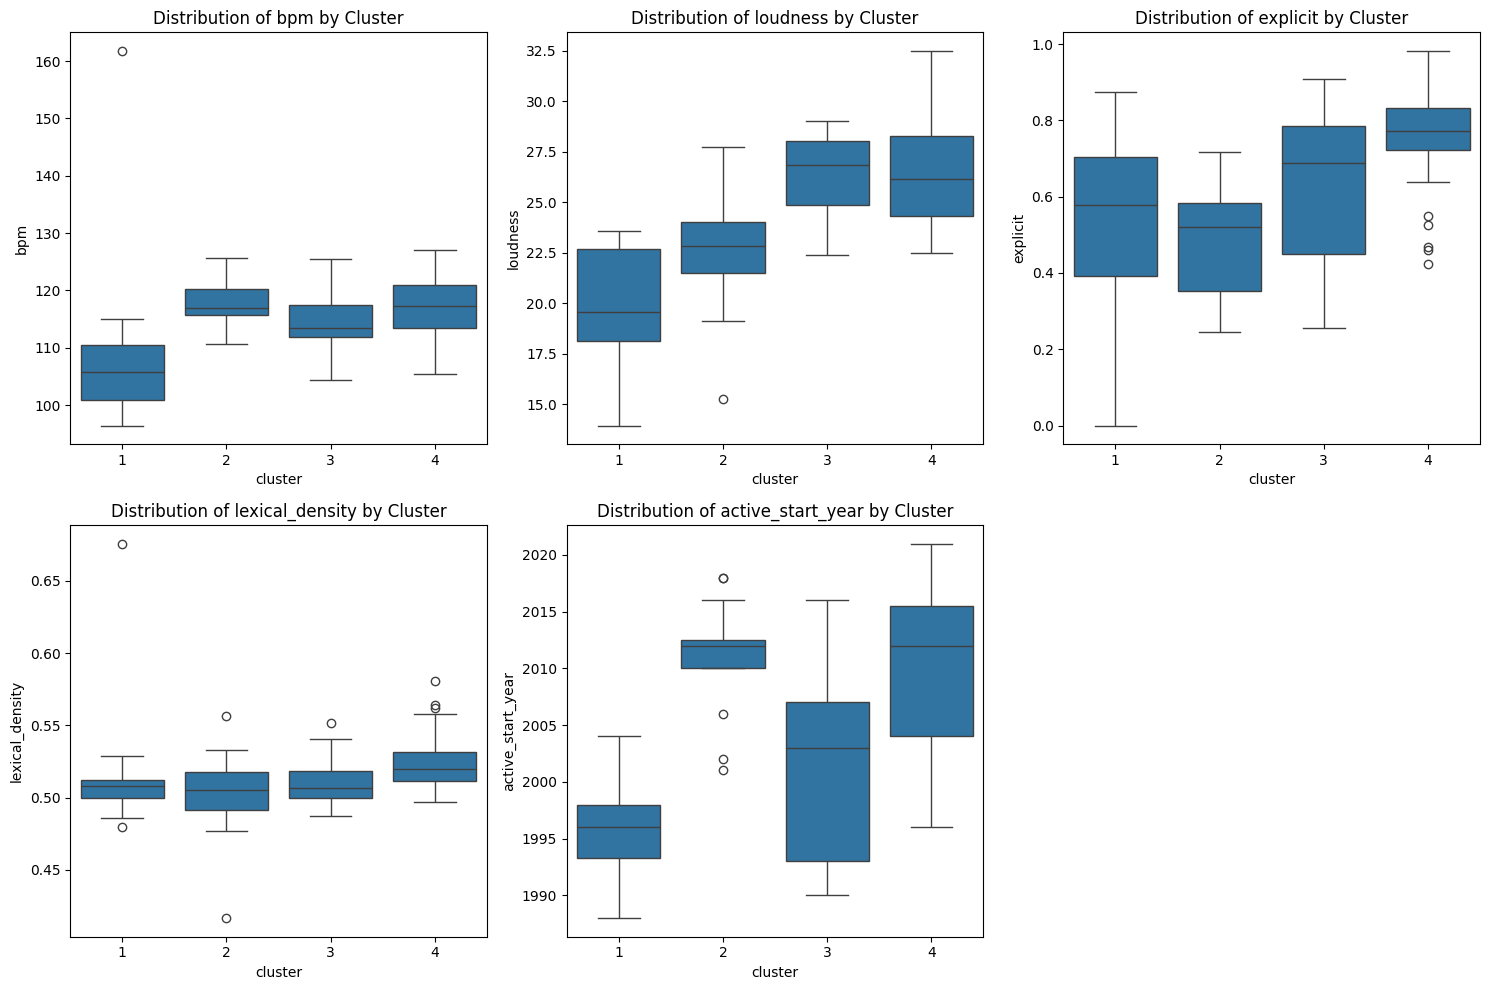

In [64]:
# Select some interesting features to avoid cluttering the plot
cols_to_plot = ['bpm', 'loudness', 'explicit', 'lexical_density', 'active_start_year']

# We use the original data merged with clusters for readability
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='cluster', y=col, data=merged_df_filtered)
    plt.title(f'Distribution of {col} by Cluster')
plt.tight_layout()
plt.show()

The graphs reveal 4 distinct profiles:

**Cluster 1 (Veterans/Classics):**

*   **Start Year:** 1990s (the oldest).
*   **Style:** Low BPM and Loudness (calmer music).
*   **Content:** Not very explicit.

**Cluster 2 (Modern Mainstream Pop):**

*   **Start Year:** Recent (post-2010).
*   **Style:** High BPM but very clean content (minimum values for `explicit`).
*   **Popularity:** Very high.

**Cluster 3 (Alternative/Rock?):**

*   **Style:** High volumes (Loudness) but lower popularity compared to mainstream.
*   **Geography:** Strongly linked to Northern Italy (see map).

**Cluster 4 (Urban/New School Trap):**

*   **Content:** The most explicit of all (maximum use of `swear_IT`).
*   **Style:** Aggressive music (maximum Loudness and BPM).
*   **Success:** Currently dominating the charts (maximum Popularity).

For n_clusters = 2, the silhouette score is: 0.167
For n_clusters = 3, the silhouette score is: 0.095
For n_clusters = 4, the silhouette score is: 0.122
For n_clusters = 5, the silhouette score is: 0.128
For n_clusters = 6, the silhouette score is: 0.132


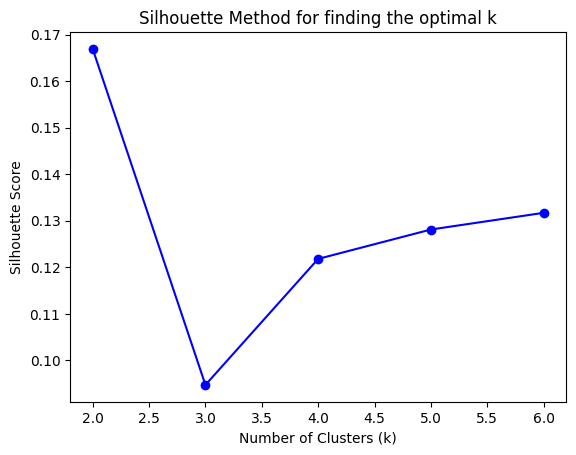

In [65]:
from sklearn.metrics import silhouette_score

scores = []
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
    silhouette_avg = silhouette_score(features_scaled, cluster_labels)
    scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the silhouette score is: {silhouette_avg:.3f}")

# Plot the results
plt.plot(range_n_clusters, scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for finding the optimal k')
plt.show()

### Observation:
The chart shows that the mathematical score is highest for k=2, indicating a strong primary division (likely between the "Old" and "New" generations).

### Choice:
However, we notice a rise in the score at k=4. This is the recommended choice for the analysis because it allows capturing important nuances (like the difference between Pop and Trap) that would be lost with only 2 groups.